In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import yfinance as yf

%matplotlib inline
sns.set(style="whitegrid")

# Define our own technical indicators
def calculate_sma(data, period):
    return data.rolling(window=period).mean()

def calculate_rsi(data, periods=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(data, fast=12, slow=26, signal=9):
    exp1 = data.ewm(span=fast, adjust=False).mean()
    exp2 = data.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line


In [4]:
# 2. Load stock data
base_path = os.path.join(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))), "data", "raw", "yfinance_data")
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA']

print(f"Loading data from: {base_path}")
stock_data = {}
for ticker in tickers:
    path = os.path.join(base_path, f"{ticker}_historical_data.csv")
    print(f"Reading file: {path}")
    df = pd.read_csv(path, parse_dates=["Date"])
    df.sort_values("Date", inplace=True)
    df.set_index("Date", inplace=True)
    stock_data[ticker] = df
    print(f"{ticker}: {df.shape}")


Loading data from: C:\Users\Admin\Documents\Data Science\predicting price moves\data\raw\yfinance_data
Reading file: C:\Users\Admin\Documents\Data Science\predicting price moves\data\raw\yfinance_data\AAPL_historical_data.csv
AAPL: (10998, 8)
Reading file: C:\Users\Admin\Documents\Data Science\predicting price moves\data\raw\yfinance_data\AMZN_historical_data.csv
AMZN: (6846, 8)
Reading file: C:\Users\Admin\Documents\Data Science\predicting price moves\data\raw\yfinance_data\GOOG_historical_data.csv
GOOG: (5020, 8)
Reading file: C:\Users\Admin\Documents\Data Science\predicting price moves\data\raw\yfinance_data\META_historical_data.csv
META: (2926, 8)
Reading file: C:\Users\Admin\Documents\Data Science\predicting price moves\data\raw\yfinance_data\MSFT_historical_data.csv
MSFT: (9672, 8)
Reading file: C:\Users\Admin\Documents\Data Science\predicting price moves\data\raw\yfinance_data\NVDA_historical_data.csv
NVDA: (6421, 8)
Reading file: C:\Users\Admin\Documents\Data Science\predicting

In [5]:
def apply_indicators(df):
    # Calculate SMAs
    df['SMA_20'] = calculate_sma(df['Close'], 20)
    df['SMA_50'] = calculate_sma(df['Close'], 50)
    
    # Calculate RSI
    df['RSI'] = calculate_rsi(df['Close'])
    
    # Calculate MACD
    df['MACD'], df['MACD_Signal'] = calculate_macd(df['Close'])
    return df

# Apply indicators to one example stock (e.g., AAPL)
aapl = stock_data['AAPL'].copy()
aapl = apply_indicators(aapl)
aapl.tail()


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,RSI,MACD,MACD_Signal
Date,,,,,,,,,,,,,
2024-07-24,224.000000,224.800003,217.130005,218.539993,218.287323,61777600,0.0,0.0,224.228500,208.474199,46.477871,4.662717,6.678882
2024-07-25,218.929993,220.850006,214.619995,217.490005,217.238556,51391200,0.0,0.0,224.440500,209.098399,38.650941,3.748082,6.092722
2024-07-26,218.699997,219.490005,216.009995,217.960007,217.708008,41601300,0.0,0.0,224.633500,209.709000,37.019471,3.026267,5.479431
2024-07-29,216.960007,219.300003,215.750000,218.240005,217.987686,36311800,0.0,0.0,225.014500,210.279400,36.042790,2.448591,4.873263
2024-07-30,219.190002,220.330002,216.119995,218.800003,218.547043,41643800,0.0,0.0,225.117001,210.858600,28.936417,2.012764,4.301163


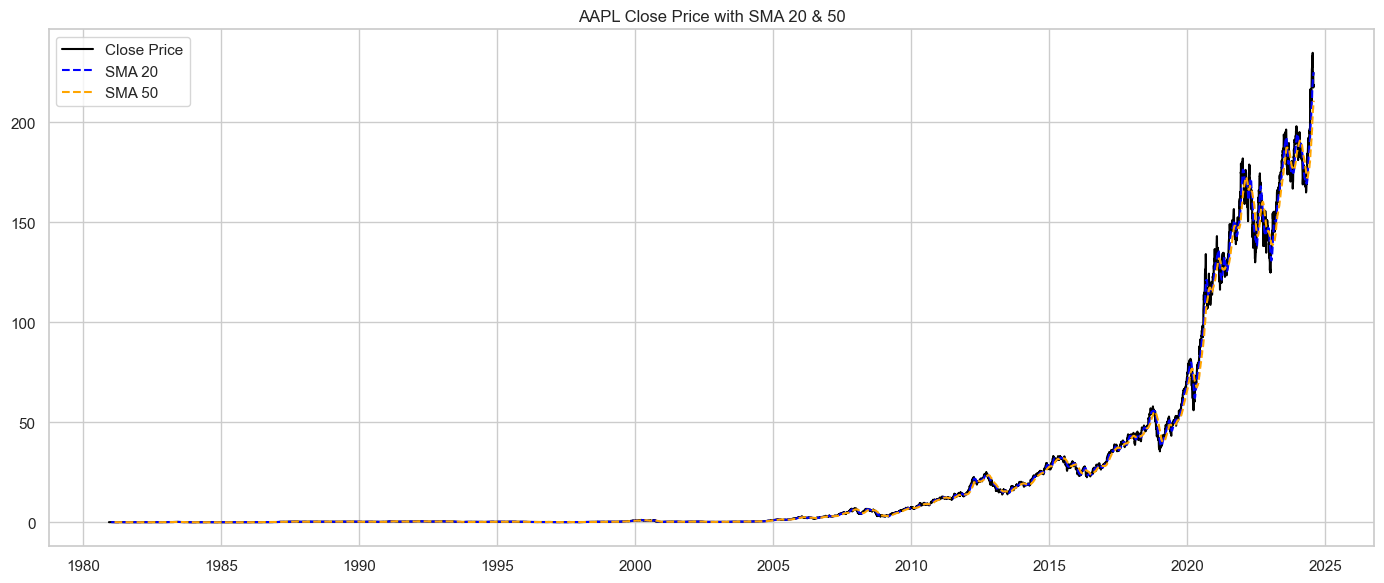

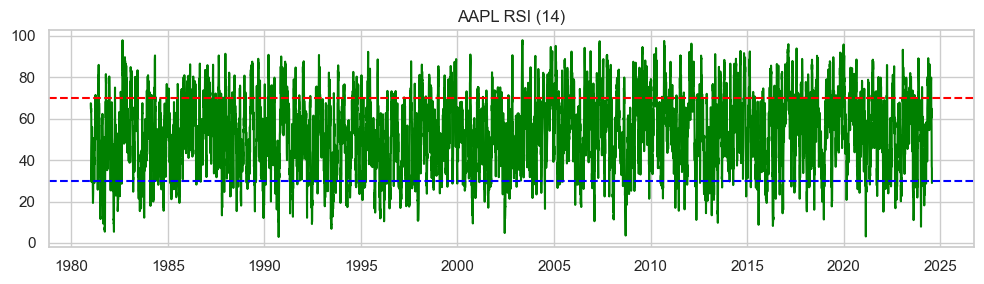

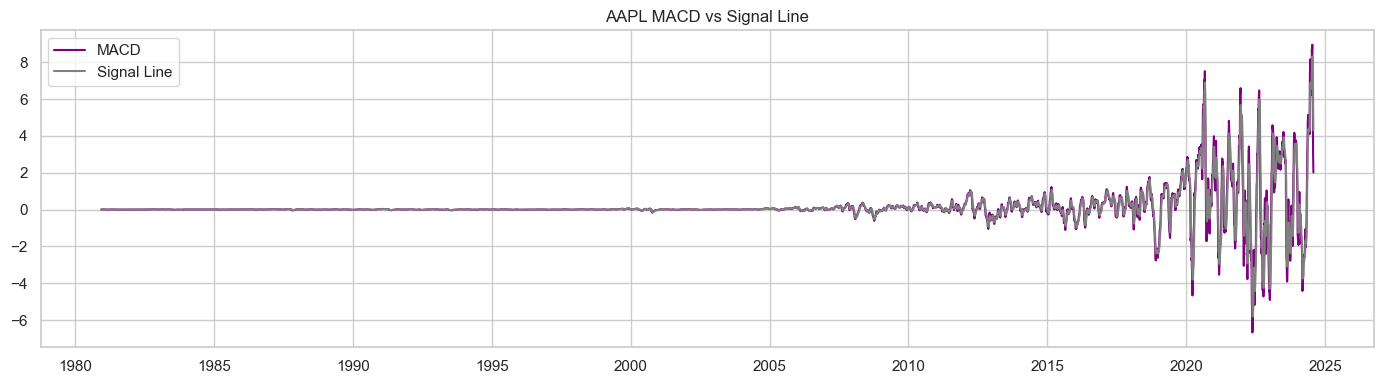

In [6]:
# SMA + Close
plt.figure(figsize=(14, 6))
plt.plot(aapl.index, aapl['Close'], label='Close Price', color='black')
plt.plot(aapl['SMA_20'], label='SMA 20', color='blue', linestyle='--')
plt.plot(aapl['SMA_50'], label='SMA 50', color='orange', linestyle='--')
plt.title("AAPL Close Price with SMA 20 & 50")
plt.legend()
plt.tight_layout()
plt.show()

# RSI
plt.figure(figsize=(10, 3))
plt.plot(aapl['RSI'], color='green')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='blue', linestyle='--')
plt.title("AAPL RSI (14)")
plt.tight_layout()
plt.show()

# MACD
plt.figure(figsize=(14, 4))
plt.plot(aapl['MACD'], label='MACD', color='purple')
plt.plot(aapl['MACD_Signal'], label='Signal Line', color='gray')
plt.title("AAPL MACD vs Signal Line")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# Get recent AAPL data using yfinance
aapl_yf = yf.Ticker("AAPL")
prices = aapl_yf.history(start="2023-01-01", end="2024-12-31")

# Calculate daily returns
returns = prices['Close'].pct_change()

# Display a sample
print("Latest daily returns:")
print(returns.tail())


Latest daily returns:
Date
2024-12-23 00:00:00-05:00    0.003065
2024-12-24 00:00:00-05:00    0.011478
2024-12-26 00:00:00-05:00    0.003176
2024-12-27 00:00:00-05:00   -0.013242
2024-12-30 00:00:00-05:00   -0.013263
Name: Close, dtype: float64


In [8]:
## Summary & Insights

- **SMA Analysis**: SMA 20 and SMA 50 help identify trend direction and crossover signals.
- **RSI**: Relative Strength Index highlighted overbought (above 70) and oversold (below 30) conditions.
- **MACD**: Captured momentum changes and potential buy/sell signals based on MACD crossovers.
- **PyNance**: Used to fetch recent metrics like returns and volume insights.

---
**References**:
- [TA-Lib documentation](https://mrjbq7.github.io/ta-lib/)
- [PyNance GitHub](https://github.com/rdcolema/pynance)
- [Investopedia: Technical Indicators](https://www.investopedia.com/terms/t/technicalindicator.asp)


SyntaxError: invalid syntax (1915368195.py, line 3)